In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


In [ ]:
df=pd.read_csv('/content/gdrive/My Drive/PhiUSIIL_Phishing_URL_Dataset.csv')
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
# Randomly sample 50,000 rows from the dataset
df = df.sample(n=5000, random_state=42)

# Save the sampled dataset to a new file (optional)
#df.to_csv('df.csv', index=False)

print("5000 rows have been successfully sampled!")


5000 rows have been successfully sampled!


In [ ]:
df.label.value_counts()

,count
label,
1,2841
0,2159


In [ ]:
df.shape

(5000, 56)

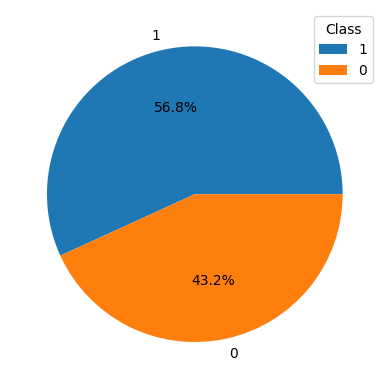

In [ ]:
import matplotlib.pyplot as plt

# Calculate label distribution
label_counts = df['label'].value_counts(normalize=True) * 100

# Plot
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
        colors=['#1f77b4', '#ff7f0e'])
plt.legend(title='Class', labels=label_counts.index.astype(str))
plt.show()

#TF-IDF

In [ ]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
'''urls = [
    "https://www.southbankmosaics.com	",
    "https://www.uni-mainz.de",
    "https://www.voicefmradio.co.uk",
    "https://www.sfnmjournal.com",
]'''
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(df.URL)

terms = tfidf_vectorizer.get_feature_names_out()

df1 = pd.DataFrame(tfidf_matrix.toarray(), columns=terms)

print(df1)


      0001  005  006512  007  00980  00ad7e3  00c72f37  019d42c4deec   02  \
0      0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
1      0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
2      0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
3      0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
4      0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
...    ...  ...     ...  ...    ...      ...       ...           ...  ...   
4995   0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
4996   0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
4997   0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
4998   0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   
4999   0.0  0.0     0.0  0.0    0.0      0.0       0.0           0.0  0.0   

       03  ...  zumic  zuobisijewelry  zvzcqq   zw  \
0     0.0  ...    0.0

In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df1,df.label,test_size=0.3)
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))

3500 1500
3500 1500


In [ ]:
y_train.value_counts()

,count
label,
1,2016
0,1484


In [ ]:
y_test.value_counts()

,count
label,
1,825
0,675


#Bag of word

In [ ]:
'''#Features Extractions

from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()
featuresVector=cv.fit_transform(df.URL)
tf=cv.get_feature_names_out()
df1 = pd.DataFrame(featuresVector.toarray(), columns=tf)

print(df1)'''

'#Features Extractions\n\nfrom sklearn.feature_extraction.text import CountVectorizer\ncv=CountVectorizer()\nfeaturesVector=cv.fit_transform(df.URL)\ntf=cv.get_feature_names_out()\ndf1 = pd.DataFrame(featuresVector.toarray(), columns=tf)\n\nprint(df1)'

In [ ]:
'''from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df1,df.label,test_size=0.8)
print(len(X_train), len(X_test))
print(len(y_train), len(y_test))'''

'from sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(df1,df.label,test_size=0.8)\nprint(len(X_train), len(X_test))\nprint(len(y_train), len(y_test))'

#Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_predicted = model.predict(X_test)
y_predicted

array([1, 0, 1, ..., 1, 0, 1])

In [ ]:
#X_test

In [ ]:
model.score(X_test, y_test)

0.9853333333333333

In [ ]:
model.predict_proba(X_test)

array([[0.17558875, 0.82441125],
       [0.78631902, 0.21368098],
       [0.09447172, 0.90552828],
       ...,
       [0.07810893, 0.92189107],
       [0.89932339, 0.10067661],
       [0.04408908, 0.95591092]])

In [ ]:
# Confusiion Matrix
# Accuracy
# Precission
# Recall
# F1-Score

In [ ]:
model.coef_

array([[-0.07268963,  0.        , -0.08696364, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
model.intercept_

array([-1.57039549])

#Confusion Matrix

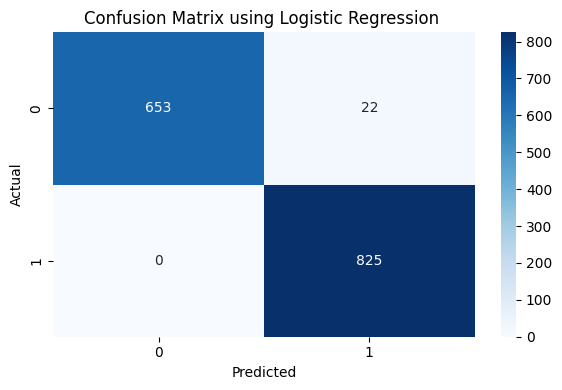

In [ ]:
# Confusiion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_predicted)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
sns.heatmap(cm,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix using Logistic Regression ')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# y_test : true labels
# y_pred : predicted labels
cm = confusion_matrix(y_test, y_predicted)

# Unpack
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (TN) : {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP) : {TP}")

Confusion Matrix:
[[653  22]
 [  0 825]]

True Negatives (TN) : 653
False Positives (FP): 22
False Negatives (FN): 0
True Positives (TP) : 825


In [ ]:
from sklearn.metrics import accuracy_score
# Accuracy
accuracy = accuracy_score(y_test, y_predicted)
print("Accuracy:", accuracy)

Accuracy: 0.9853333333333333


In [ ]:
from sklearn.metrics import precision_score
# Precission
# For binary classification
precision = precision_score(y_test, y_predicted)
print("Precision:", precision)


Precision: 0.974025974025974


In [ ]:
from sklearn.metrics import recall_score
# Recall
recall = recall_score(y_test, y_predicted)
print("Recall:", recall)

Recall: 1.0


In [ ]:
from sklearn.metrics import f1_score# F1-Score
f1 = f1_score(y_test, y_predicted)
print("F1-Score:", f1)

F1-Score: 0.9868421052631579


#Naive Bayes


In [ ]:
from sklearn. naive_bayes import GaussianNB, MultinomialNB
model = GaussianNB()
model.fit(X_train,y_train)

GaussianNB()

In [ ]:
model.score(X_test,y_test )

0.956

In [ ]:
mn = MultinomialNB()
mn.fit(X_train,y_train)
mn.score(X_test,y_test)

0.958

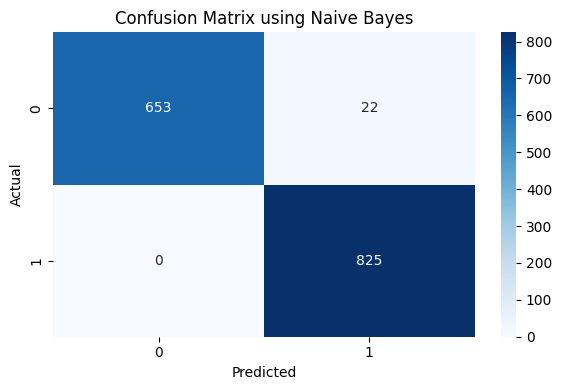

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_predicted)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
sns.heatmap(cm,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix using Naive Bayes')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# y_test : true labels
# y_pred : predicted labels
cm = confusion_matrix(y_test, y_predicted)

# Unpack
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (TN) : {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP) : {TP}")

Confusion Matrix:
[[653  22]
 [  0 825]]

True Negatives (TN) : 653
False Positives (FP): 22
False Negatives (FN): 0
True Positives (TP) : 825


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_predicted)
print("Accuracy:", accuracy)

Accuracy: 0.9853333333333333


In [ ]:
from sklearn.metrics import precision_score# Precission
precision = precision_score(y_test, y_predicted)
print("Precision:", precision)


Precision: 0.974025974025974


In [ ]:
from sklearn.metrics import recall_score# Recall
recall = recall_score(y_test, y_predicted)
print("Recall:", recall)

Recall: 1.0


In [ ]:
from sklearn.metrics import f1_score# F1-Score
f1 = f1_score(y_test, y_predicted)
print("F1-Score:", f1)

F1-Score: 0.9868421052631579


#decission tree

In [ ]:
from sklearn import tree
model=tree.DecisionTreeClassifier()

In [ ]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
model.score(X_test, y_test)

0.99

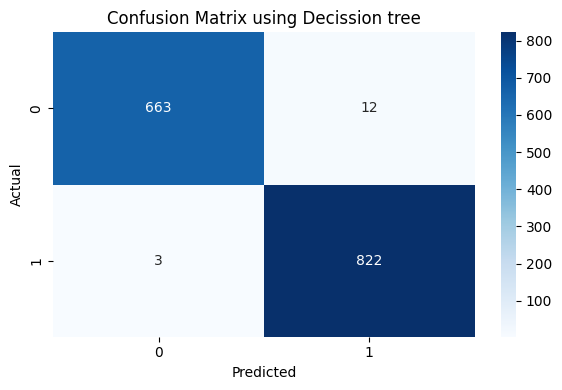

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
sns.heatmap(cm,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix using Decission tree')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# y_test : true labels
# y_pred : predicted labels
cm = confusion_matrix(y_test, y_pred)

# Unpack
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (TN) : {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP) : {TP}")

Confusion Matrix:
[[663  12]
 [  3 822]]

True Negatives (TN) : 663
False Positives (FP): 12
False Negatives (FN): 3
True Positives (TP) : 822


In [ ]:
from sklearn.metrics import accuracy_score
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.99


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9856115107913669


In [ ]:
from sklearn.metrics import recall_score# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9963636363636363


In [ ]:
from sklearn.metrics import f1_score
# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

F1-Score: 0.9909584086799277


#Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
model.score(X_test, y_test)

0.99

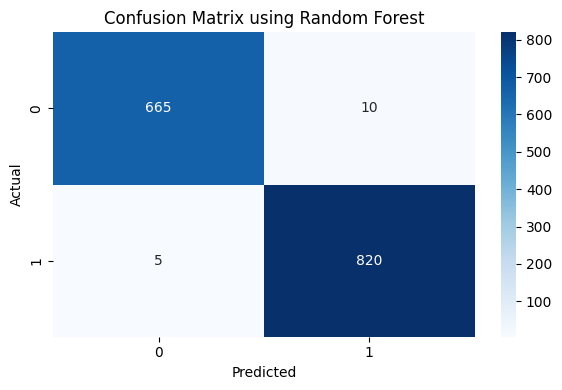

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
sns.heatmap(cm,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix using Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# y_test : true labels
# y_pred : predicted labels
cm = confusion_matrix(y_test, y_pred)

# Unpack
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (TN) : {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP) : {TP}")

Confusion Matrix:
[[665  10]
 [  5 820]]

True Negatives (TN) : 665
False Positives (FP): 10
False Negatives (FN): 5
True Positives (TP) : 820


In [ ]:
from sklearn.metrics import accuracy_score
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.99


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9879518072289156


In [ ]:
from sklearn.metrics import recall_score
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9939393939393939


In [ ]:
from sklearn.metrics import f1_score
# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

F1-Score: 0.9909365558912386


#Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import SVC

In [ ]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
model.score(X_test, y_test)

0.9913333333333333

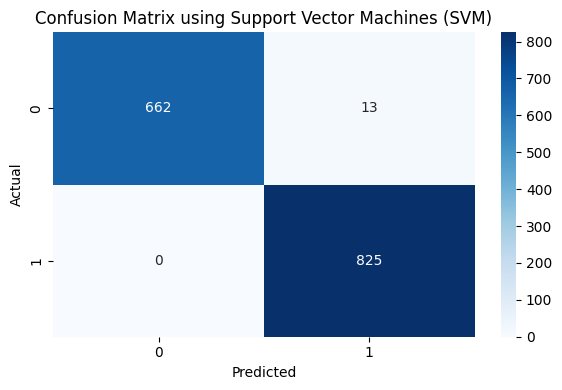

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
sns.heatmap(cm,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix using Support Vector Machines (SVM)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# y_test : true labels
# y_pred : predicted labels
cm = confusion_matrix(y_test, y_pred)

# Unpack
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (TN) : {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP) : {TP}")

Confusion Matrix:
[[662  13]
 [  0 825]]

True Negatives (TN) : 662
False Positives (FP): 13
False Negatives (FN): 0
True Positives (TP) : 825


In [ ]:
from sklearn.metrics import accuracy_score
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9913333333333333


In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9844868735083532


In [ ]:
from sklearn.metrics import recall_score
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 1.0


In [ ]:
from sklearn.metrics import f1_score
# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

F1-Score: 0.9921828021647625


#K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
model = KNeighborsClassifier()
model.fit(X_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
model.score(X_test, y_test)

0.9406666666666667

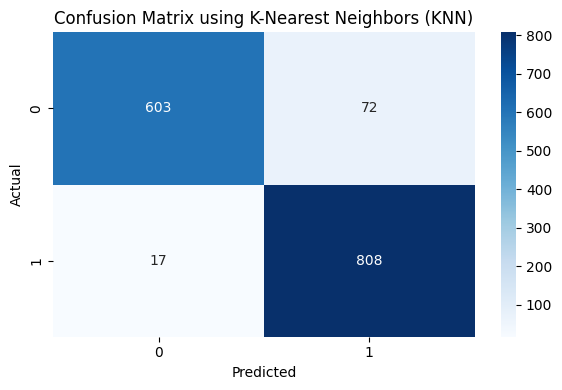

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
sns.heatmap(cm,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix using K-Nearest Neighbors (KNN)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

# y_test : true labels
# y_pred : predicted labels
cm = confusion_matrix(y_test, y_pred)

# Unpack
TN, FP, FN, TP = cm.ravel()

print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives (TN) : {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP) : {TP}")

Confusion Matrix:
[[603  72]
 [ 17 808]]

True Negatives (TN) : 603
False Positives (FP): 72
False Negatives (FN): 17
True Positives (TP) : 808


In [ ]:
from sklearn.metrics import accuracy_score
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9406666666666667


In [ ]:
from sklearn.metrics import precision_score
# Precission
# For binary classification
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.9181818181818182


In [ ]:
from sklearn.metrics import recall_score
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.9793939393939394


In [ ]:
from sklearn.metrics import f1_score
# F1-Score
f1 = f1_score(y_test, y_pred)
print("F1-Score:", f1)

F1-Score: 0.9478005865102639


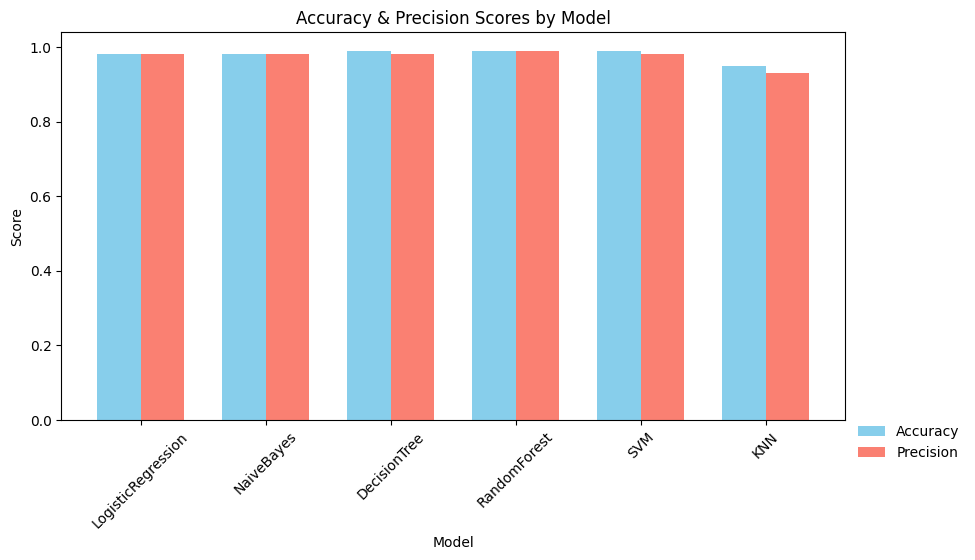

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['LogisticRegression', 'NaiveBayes', 'DecisionTree', 'RandomForest', 'SVM', 'KNN']

# Accuracy and Precision scores
accuracy_scores = [0.98, 0.98, 0.99, 0.99, 0.99, 0.95]
precision_scores = [0.98, 0.98, 0.98, 0.99, 0.98, 0.93]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

# Plotting bars
bars1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, precision_scores, width, label='Precision', color='salmon')

# Labels and title
ax.set_ylabel('Score')
ax.set_xlabel('Model')
ax.set_title('Accuracy & Precision Scores by Model')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)

# Legend on the bottom right just over the x-axis
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 0.02), frameon=False)

# Adjust layout to make room for legend
plt.tight_layout()
plt.subplots_adjust(right=0.85, bottom=0.15)

plt.show()


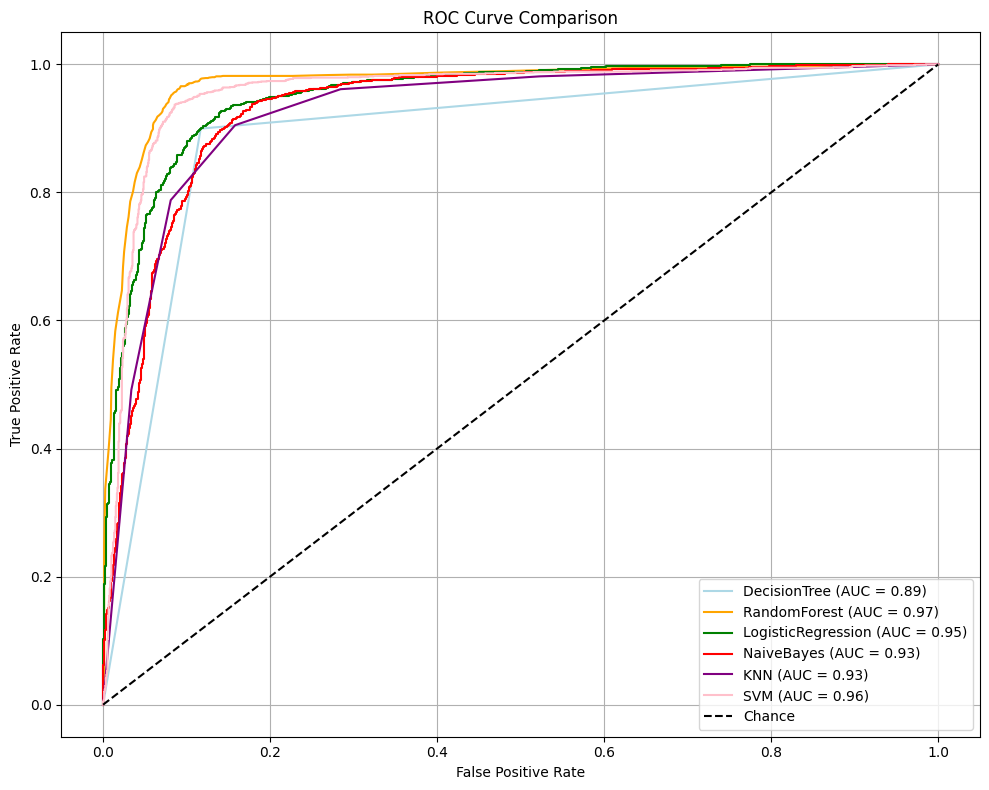

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import numpy as np
from sklearn.datasets import make_classification

# Generate synthetic binary classification data
X, y = make_classification(n_samples=10000, n_features=20, n_classes=2, random_state=42)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize classifiers (excluding MLP)
models = {
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "LogisticRegression": LogisticRegression(),
    "NaiveBayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

# Plot setup
plt.figure(figsize=(10, 8))
plt.title('ROC Curve Comparison')

# Define colors for consistency
colors = ['lightblue', 'orange', 'green', 'red', 'purple', 'pink']

# Plot ROC curve for each classifier
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f'{name} (AUC = {roc_auc:.2f})')

# Plot diagonal chance line
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Chance')

# Add labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# Save figure if needed
# plt.savefig('final_roc_comparison.png', dpi=300)

# Show plot
plt.show()
